In [4]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================================================
# REPRODUCIBILITY CONTROL
# This ensures consistent results every time we run.
# =========================================================

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed fixed:", SEED)

TensorFlow version: 2.16.2
Random seed fixed: 42


In [6]:
# =========================================================
# LOAD OXFORD FLOWERS DATASET
# =========================================================

dataset = load_dataset("nkirschi/oxford-flowers")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7169
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1020
    })
})


In [8]:
# =========================================================
# PREPROCESS DATA
# =========================================================

IMG_SIZE = 224

def prepare_dataset(split):
    images = []
    labels = []
    
    for item in dataset[split]:
        # Resize image
        image = item['image'].resize((IMG_SIZE, IMG_SIZE))
        
        # Convert to numpy
        image_array = np.array(image, dtype=np.float32)
        
        # Apply EfficientNet preprocessing
        image_array = preprocess_input(image_array)
        
        images.append(image_array)
        labels.append(item['label'])
    
    return np.array(images), np.array(labels)

X_train, y_train_raw = prepare_dataset('train')
X_test, y_test_raw = prepare_dataset('test')

# Determine number of classes
num_classes = len(np.unique(y_train_raw))

# Convert labels to categorical for neural network
y_train = to_categorical(y_train_raw, num_classes)
y_test = to_categorical(y_test_raw, num_classes)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Number of classes:", num_classes)

Training shape: (7169, 224, 224, 3)
Testing shape: (1020, 224, 224, 3)
Number of classes: 102


In [10]:
# =========================================================
# DATA AUGMENTATION (FOR NEURAL NETWORK ONLY)
# =========================================================

datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(X_train)

In [12]:
# =========================================================
# BUILD TRANSFER LEARNING MODEL
# =========================================================

# Load pretrained EfficientNet
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model initially
base_model.trainable = False

# Build classification head
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 102)            │        52,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,757,769 (18.15 MB)

 Trainable params: 708,198 (2.70 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
# =========================================================
# CALLBACKS
# =========================================================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_transfer_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [16]:
# =========================================================
# TRAIN PHASE 1 (FROZEN BASE MODEL)
# =========================================================

# Safety check to avoid NameError
if 'model' not in globals():
    raise Exception("Model is not defined. Please run the model-building cell first.")

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 89s 384ms/step - accuracy: 0.5008 - loss: 2.8405 - val_accuracy: 0.7314 - val_loss: 1.6753
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 90s 399ms/step - accuracy: 0.7584 - loss: 1.4955 - val_accuracy: 0.8363 - val_loss: 1.1850
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 92s 408ms/step - accuracy: 0.8180 - loss: 1.2016 - val_accuracy: 0.8667 - val_loss: 1.0525
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 98s 437ms/step - accuracy: 0.8478 - loss: 1.0566 - val_accuracy: 0.8765 - val_loss: 0.9274
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 103s 458ms/step - accuracy: 0.8622 - loss: 0.9425 - val_accuracy: 0.8922 - val_loss: 0.8499
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 99s 437ms/step - accuracy: 0.8715 - loss: 0.8770 - val_accuracy: 0.8922 - val_loss: 0.7975
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 100s 442ms/step - accuracy: 0.8771 - loss: 0.8517 - val_accuracy: 0.8990 - val_loss: 0.7798
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 120s 533ms/step - accuracy: 0.8799 - loss

In [18]:
# =========================================================
# FINE-TUNING PHASE
# =========================================================

if 'model' not in globals():
    raise Exception("Model is not defined. Please run previous cells.")

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 137s 588ms/step - accuracy: 0.7947 - loss: 1.4006 - val_accuracy: 0.8882 - val_loss: 0.9044
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 131s 584ms/step - accuracy: 0.8551 - loss: 1.1131 - val_accuracy: 0.9020 - val_loss: 0.8874
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 137s 609ms/step - accuracy: 0.8890 - loss: 0.9581 - val_accuracy: 0.9108 - val_loss: 0.8313
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 136s 605ms/step - accuracy: 0.9000 - loss: 0.8609 - val_accuracy: 0.9147 - val_loss: 0.7881
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 135s 601ms/step - accuracy: 0.9125 - loss: 0.8067 - val_accuracy: 0.9196 - val_loss: 0.7518


In [20]:
# =========================================================
# FINAL EVALUATION
# =========================================================

nn_loss, nn_accuracy = model.evaluate(X_test, y_test)
print("Neural Network Test Accuracy:", nn_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step - accuracy: 0.8882 - loss: 0.9044
Neural Network Test Accuracy: 0.8882352709770203


In [22]:
# =========================================================
# DECISION TREE BASELINE
# =========================================================

# Flatten images for classical ML
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

dt_model = DecisionTreeClassifier(
    max_depth=25,
    random_state=SEED
)

dt_model.fit(X_train_flat, y_train_raw)

dt_predictions = dt_model.predict(X_test_flat)

dt_accuracy = accuracy_score(y_test_raw, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.0784313725490196


In [24]:
# =========================================================
#Comparision model
# =========================================================

print("================================")
print("MODEL COMPARISON")
print("================================")
print(f"Neural Network Accuracy: {nn_accuracy:.4f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

MODEL COMPARISON
Neural Network Accuracy: 0.8882
Decision Tree Accuracy: 0.0784


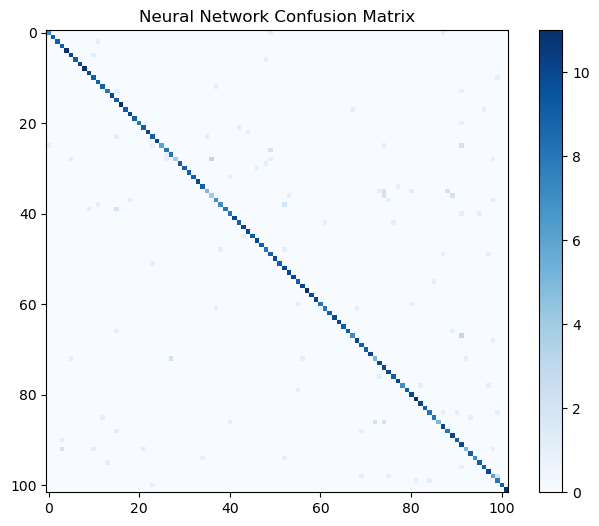

              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       1.00      1.00      1.00         9
           2       1.00      0.90      0.95        10
           3       0.75      1.00      0.86         9
           4       1.00      1.00      1.00        11
           5       0.83      0.91      0.87        11
           6       1.00      0.90      0.95        10
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00        11
           9       0.91      1.00      0.95        10
          10       0.82      0.90      0.86        10
          11       0.82      1.00      0.90         9
          12       0.90      0.90      0.90        10
          13       0.89      0.80      0.84        10
          14       1.00      1.00      1.00        10
          15       0.60      1.00      0.75         9
          16       1.00      1.00      1.00        11
          17       1.00    

In [26]:
# =========================================================
#Confusion Matrix
# =========================================================

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_raw, y_pred_classes)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.title("Neural Network Confusion Matrix")
plt.colorbar()
plt.show()

print(classification_report(y_test_raw, y_pred_classes, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


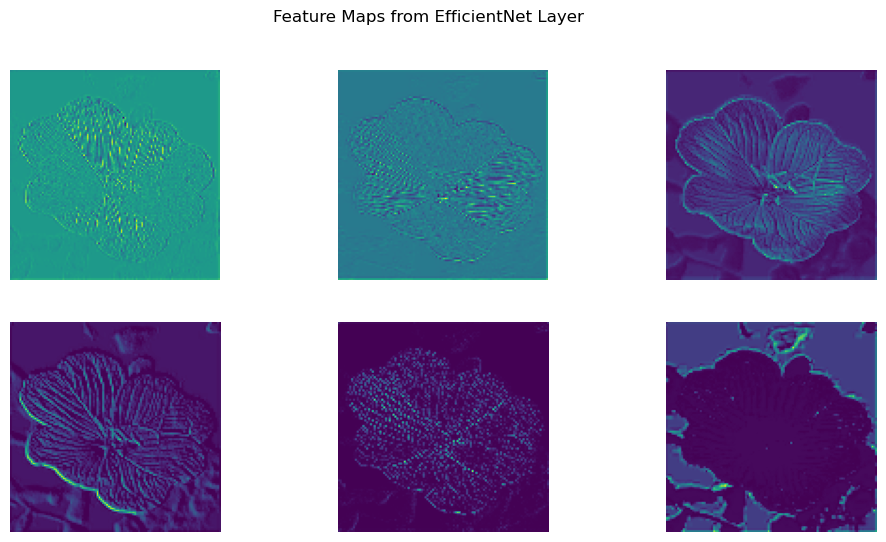

In [28]:
# =========================================================
# FEATURE MAP VISUALISATION (CORRECT & STABLE VERSION)
# =========================================================

# Select one image
sample_image = X_test[0]
sample_image = np.expand_dims(sample_image, axis=0)

# Build feature extractor from base_model only
feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.layers[20].output  # early convolution layer
)

# Get feature maps
feature_maps = feature_extractor.predict(sample_image)

# Plot first 6 channels
plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Feature Maps from EfficientNet Layer")
plt.show()

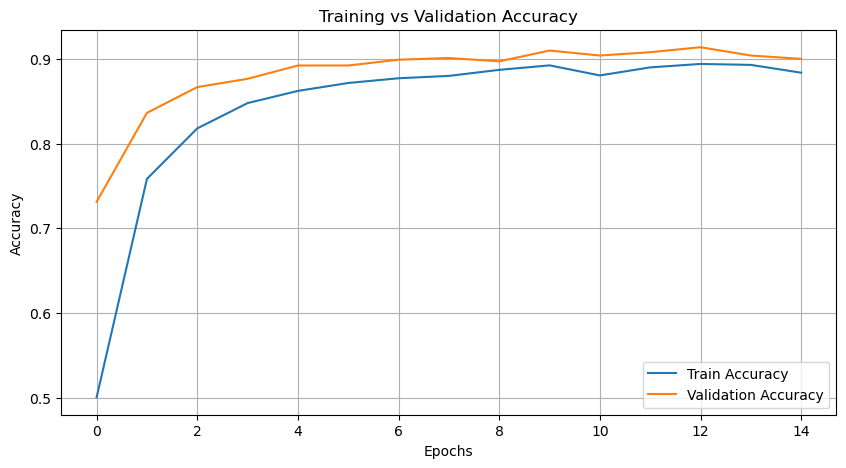

In [30]:
# =========================================================
# TRAINING HISTORY VISUALISATION (NEW)
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


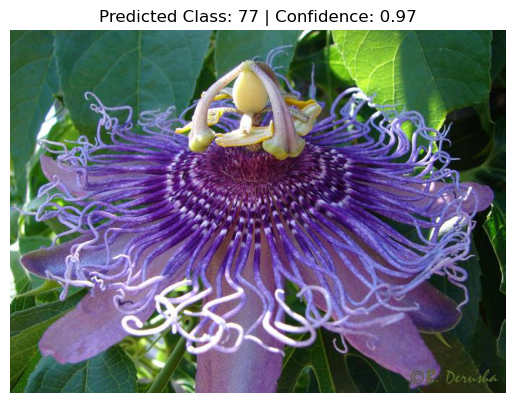

True Label: 77


In [76]:
# =========================================================
# RANDOM TEST IMAGE PREDICTION (NEW)
# =========================================================

index = random.randint(0, len(X_test)-1)

sample = X_test[index:index+1]

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

# Display original image instead of processed tensor
plt.imshow(dataset["test"][index]["image"])

plt.title(f"Predicted Class: {predicted_class} | Confidence: {confidence:.2f}")

plt.axis('off')

plt.show()

print("True Label:", y_test_raw[index])


In [78]:
# =========================================================
# SAVE FINAL MODEL
# =========================================================

model.save("flower_classifier_model.keras")

print("Model saved successfully.")


Model saved successfully.


In [1]:
# =========================================================
# INTERACTIVE IMAGE PREDICTION
# =========================================================

import tkinter as tk
from tkinter import filedialog

def predict_new_image():

    file_path = filedialog.askopenfilename()

    if file_path == "":
        print("No image selected")
        return

    img = Image.open(file_path).convert("RGB")

    img = img.resize((IMG_SIZE, IMG_SIZE))

    img_array = np.array(img, dtype=np.float32)

    img_array = preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    plt.imshow(img)

    plt.title(f"Predicted Class: {predicted_class} | Confidence: {confidence:.2f}")

    plt.axis("off")

    plt.show()


root = tk.Tk()

root.withdraw()

print("Select an image for prediction")

predict_new_image()

Select an image for prediction
No image selected
